In [1]:
import pyuvdata
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


In [2]:
uv = pyuvdata.UVData()

In [3]:
uv.read("/fast/rbyrne/20260407_123010-123201_52MHz.ms")

In [4]:
uv.phase_to_time(np.mean(uv.time_array))
uv.data_array[np.where(uv.flag_array)] = np.nan + 1j*np.nan

In [5]:
uv.select(polarizations=[-5])

In [6]:
np.shape(uv.data_array)

(745536, 354, 1)

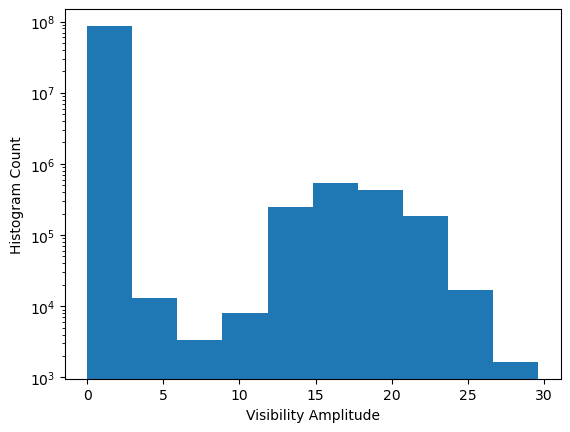

In [7]:
plt.hist(np.abs(uv.data_array.flatten()))
plt.xlabel("Visibility Amplitude")
plt.ylabel("Histogram Count")
plt.yscale("log")

In [8]:
uv.uvw_array

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 3.80049212e+01,  6.26215892e+02,  6.24146281e-01],
       [-3.26819418e+01,  7.38031156e+01,  2.18972776e-01],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 8.21372480e+02,  1.83072496e+02,  2.44602335e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],
      shape=(745536, 3))

Mean of empty slice


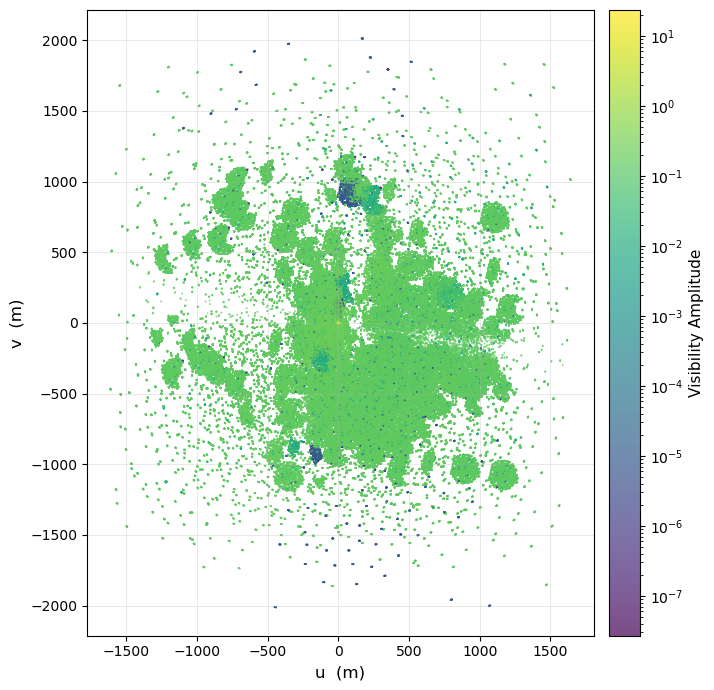

In [9]:
x = uv.uvw_array[:, 0]
y = uv.uvw_array[:, 1]
c = np.nanmean(np.abs(uv.data_array[:, :, 0]), axis=1)
 
fig, ax = plt.subplots(figsize=(8, 7))
 
sc = ax.scatter(
    x, y,
    c=c,
    cmap="viridis",
    s=2,                  # point size — adjust as needed
    alpha=0.7,
    linewidths=0,
    norm=mcolors.LogNorm(),
)
 
cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("Visibility Amplitude", fontsize=11)
 
ax.set_xlabel("u  (m)", fontsize=12)
ax.set_ylabel("v  (m)", fontsize=12)
ax.set_aspect("equal")
ax.grid(True, linewidth=0.4, alpha=0.5)
 
plt.tight_layout()
plt.show()

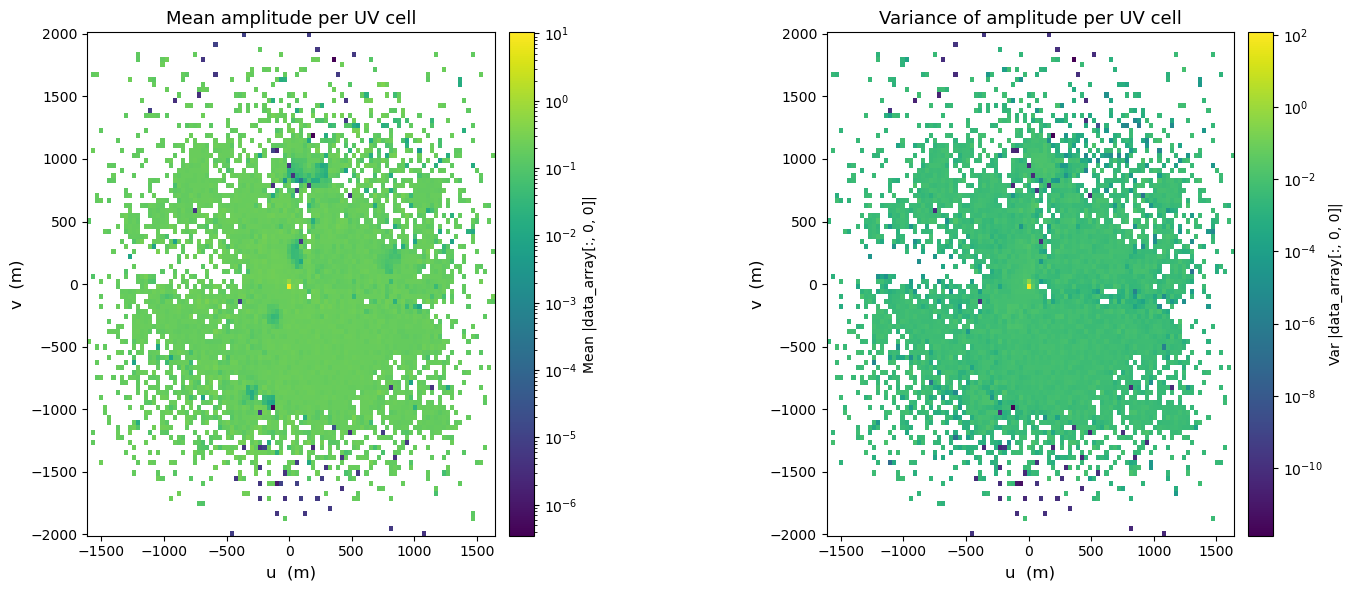

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import binned_statistic_2d
 
# --- Extract plot data ---
x = uv.uvw_array[:, 0]
y = uv.uvw_array[:, 1]
c = np.abs(uv.data_array[:, 0, 0])
 
# --- Mask NaN/inf values ---
mask = np.isfinite(c)
x, y, c = x[mask], y[mask], c[mask]
 
# --- Grid into UV cells ---
n_bins = 100  # adjust cell resolution as needed
 
mean_stat, x_edges, y_edges, _ = binned_statistic_2d(
    x, y, c, statistic="mean", bins=n_bins
)
var_stat, _, _, _ = binned_statistic_2d(
    x, y, c, statistic=np.var, bins=n_bins
)
 
# Transpose: binned_statistic_2d returns (nx, ny), imshow expects (ny, nx)
mean_stat = mean_stat.T
var_stat  = var_stat.T
 
extent = [x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]]
 
# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
 
for ax, data, title, label in zip(
    axes,
    [mean_stat, var_stat],
    ["Mean amplitude per UV cell", "Variance of amplitude per UV cell"],
    ["Mean |data_array[:, 0, 0]|", "Var |data_array[:, 0, 0]|"],
):
    valid = data[np.isfinite(data) & (data > 0)]
    norm = mcolors.LogNorm(vmin=valid.min(), vmax=valid.max())
 
    im = ax.imshow(
        data,
        origin="lower",
        extent=extent,
        norm=norm,
        cmap="viridis",
        aspect="equal",
        interpolation="none",
    )
 
    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label(label, fontsize=10)
 
    ax.set_xlabel("u  (m)", fontsize=12)
    ax.set_ylabel("v  (m)", fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.grid(False)
 
plt.tight_layout()
plt.show()